# ISO 20414:2020 — Test 12: Stair flow rates

100 occupants funnel through a centred stair opening of width 1.0, 1.2, 1.4, 1.6, 1.8 m (ISO 20414:2020 Table 13). The aim is to confirm that an increase in stair width leads to an increase in agent flow rate. The stair strip carries a **`speed_factor = 0.5` zone** (agents cross it at 0.5 m/s) — the speed-factor convention ISO Test 3/12 describe for stairs. The factor is constant across runs, so width is the only driver of the difference in emergent flow.

In [1]:
from datetime import datetime

print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 08 July 2026, 10:06 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
        "figure.figsize": (8, 5),
    }
)

In [4]:
import json
import tempfile

from scenario_builders.iso12_stair_flow import (
    STAIR_WIDTHS,
    build_geometry_wkt,
    build_raw_scenario,
    measure_flow,
)

## Scenario check — geometry and trajectories

Confirm the simulated layout: a feeding room with a centred stair (here width 1.4 m) carrying a `speed_factor = 0.5` zone and an exit at the top. Occupants funnel from the room up the stair.

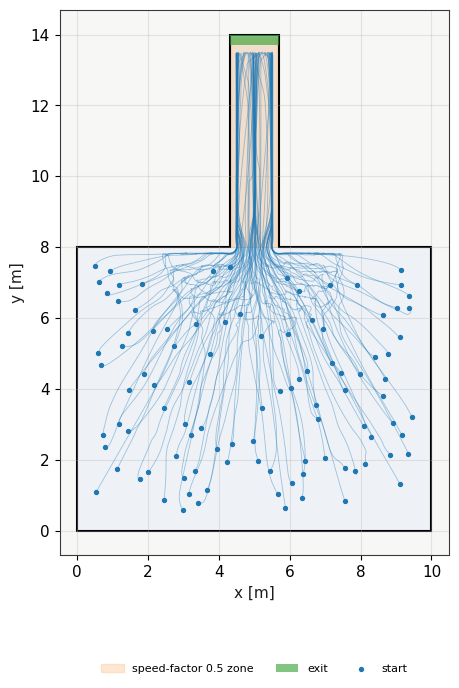

1

In [5]:
_raw = build_raw_scenario(1.4)
with tempfile.TemporaryDirectory() as _d:
    _p = Path(_d)
    (_p / "config.json").write_text(json.dumps(_raw, indent=2), encoding="utf-8")
    (_p / "geometry.wkt").write_text(build_geometry_wkt(1.4), encoding="utf-8")
    scen = load_scenario(str(_p))
    _res = run_scenario(scen, seed=42)
tdf = _res.trajectory_dataframe()
poly = scen.walkable_polygon
fig, ax = plt.subplots(figsize=(6, 7))
gx, gy = poly.exterior.xy
ax.fill(gx, gy, facecolor="#eef2f7", edgecolor="k", lw=1.5, zorder=0)
for interior in poly.interiors:
    ix, iy = interior.xy
    ax.fill(ix, iy, facecolor="white", edgecolor="k", lw=1.0, zorder=1)
for z in scen.zones.values():
    zx = [c[0] for c in z["coordinates"]]
    zy = [c[1] for c in z["coordinates"]]
    ax.fill(
        zx,
        zy,
        facecolor="tab:orange",
        alpha=0.18,
        edgecolor="tab:orange",
        zorder=1,
        label=f"speed-factor {z.get('speed_factor')} zone",
    )
for e in scen.exits.values():
    ex = [c[0] for c in e["coordinates"]]
    ey = [c[1] for c in e["coordinates"]]
    ax.fill(ex, ey, facecolor="tab:green", alpha=0.6, zorder=2, label="exit")
for _, sub in tdf.sort_values(["id", "frame"]).groupby("id"):
    ax.plot(sub.x, sub.y, color="tab:blue", lw=0.6, alpha=0.4, zorder=3)
starts = tdf.sort_values(["id", "frame"]).groupby("id").first()
ax.scatter(starts.x, starts.y, s=8, color="tab:blue", zorder=4, label="start")
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(
    uniq.values(),
    uniq.keys(),
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()
_res.cleanup()

## Sweep stair widths

Each width is materialised as a scenario directory (`config.json` + `geometry.wkt`) and loaded with `load_scenario`.

In [6]:
rows = []
for w in STAIR_WIDTHS:
    raw = build_raw_scenario(w)
    with tempfile.TemporaryDirectory() as d:
        p = Path(d)
        (p / "config.json").write_text(json.dumps(raw, indent=2), encoding="utf-8")
        (p / "geometry.wkt").write_text(build_geometry_wkt(w), encoding="utf-8")
        scenario = load_scenario(str(p))
        r = run_scenario(scenario, seed=42)
        rows.append(measure_flow(r.trajectory_dataframe(), r.frame_rate, w))
        r.cleanup()
flow = pd.DataFrame(rows)
flow

,width,crossed,flow_p_s,specific_flow_p_m_s
0,1.0,100,1.179976,1.179976
1,1.2,100,1.504559,1.253799
2,1.4,100,1.806569,1.290407
3,1.6,100,2.016293,1.260183
4,1.8,100,2.462687,1.368159


## Plot flow rate vs stair width

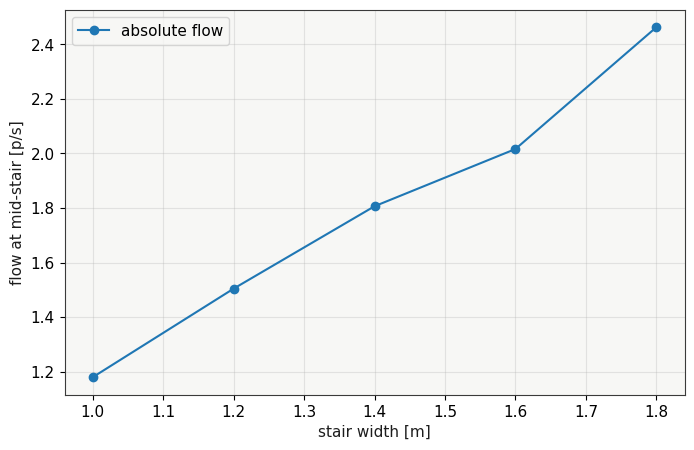

In [7]:
fig, ax = plt.subplots()
ax.plot(flow["width"], flow["flow_p_s"], "o-", label="absolute flow")
ax.set_xlabel("stair width [m]")
ax.set_ylabel("flow at mid-stair [p/s]")
ax.legend()
plt.show()

## Acceptance

Flow rate should increase with stair width: the widest stair must exceed the narrowest, and the linear trend must have positive slope.

In [8]:
f = flow.dropna(subset=["flow_p_s"])
slope = np.polyfit(f["width"], f["flow_p_s"], 1)[0]
print(
    f"flow(1.8 m) = {f.flow_p_s.iloc[-1]:.3f} p/s, flow(1.0 m) = {f.flow_p_s.iloc[0]:.3f} p/s, "
    f"slope = {slope:.3f} p/s per m"
)
assert slope > 0, flow
assert f["flow_p_s"].iloc[-1] > f["flow_p_s"].iloc[0], flow

flow(1.8 m) = 2.463 p/s, flow(1.0 m) = 1.180 p/s, slope = 1.539 p/s per m
